Exploratory Data Analysis

In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision




In [3]:
from torchvision import datasets, transforms

#from torch.utils.data import DataLoader

In [4]:
pwd

'c:\\Users\\bpham\\Documents\\HomeWork\\Pokemon-Card-Authenticator\\notebooks'

In [4]:
%cd ..

c:\Users\bpham\Documents\HomeWork\Pokemon-Card-Authenticator


C:\Users\bpham\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
### Loading Data in

card_transforms = transforms.Compose([transforms.Resize((224,224)), 
                                      transforms.ToTensor()
                                      ])


train_data= datasets.ImageFolder(root="dataset/train", transform =  card_transforms)








In [6]:
### Checking lengths of total, real , and fake data


full_length = len(train_data)

real_count = 0

fake_count =0

for (X,y) in train_data:
    y = int(y)
    if y == 0:
        fake_count +=1
    else:
        real_count+=1




print(f"Full Length of Set {full_length} | Real Amount of Cards {real_count} ({real_count/full_length* 100:.2f} %) | Fake Amount of Cards {fake_count} ({fake_count/full_length *100:.2f}) %")


#Imbalanced set

Full Length of Set 373 | Real Amount of Cards 250 (67.02 %) | Fake Amount of Cards 123 (32.98) %


In [7]:
### Checking shape of each image

test_image, test_label = train_data[0]

test_image.shape

testing = test_image.permute(1,2,0)

testing.shape



#3 color channels and height and width set to 224...

torch.Size([224, 224, 3])

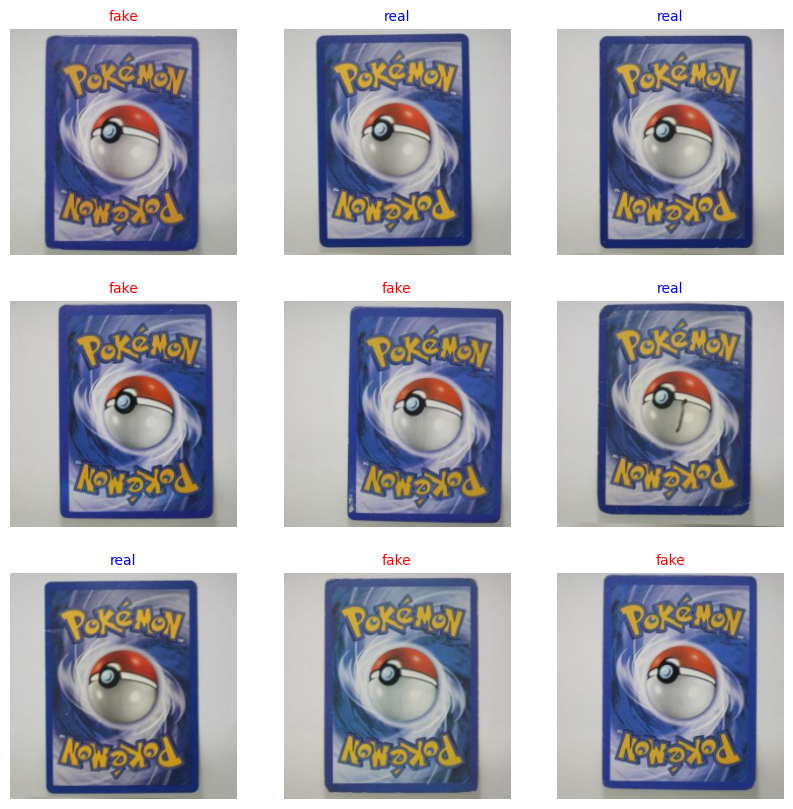

In [8]:
### Seeing Random Batches of Cards (Real/Fake)




class_names = train_data.classes

fig = plt.figure(figsize=(10,10))

rows,columns = 3,3

for x in range (1, rows*columns +1):
    random_index = torch.randint(0,len(train_data), size = [1])
    image,label = train_data[random_index]
    fig.add_subplot(rows,columns,x)
    plt.imshow(image.permute(1,2,0))
    if label == 0: 
        plt.title(class_names[label], c = "r", fontsize= 10)
    else:
        plt.title(class_names[label], c = "b" ,fontsize = 10)

    plt.axis(False)





In [ ]:
### Side by side Comparison


# Separate them into two lists
fig = plt.figure(figsize = (9,9))

rows, columns = 1,2

real_list = []

fake_list = []


for (X,y) in train_data:
    y = int(y)
    if y==0:
        fake_list.append((X,y))
    else:
        real_list.append((X,y))





if len(real_list) +len(fake_list) == len(train_data):
    print("Transfer Successful")
else:
    print("Transfer Failed")






Transfer Successful


<Figure size 900x900 with 0 Axes>

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

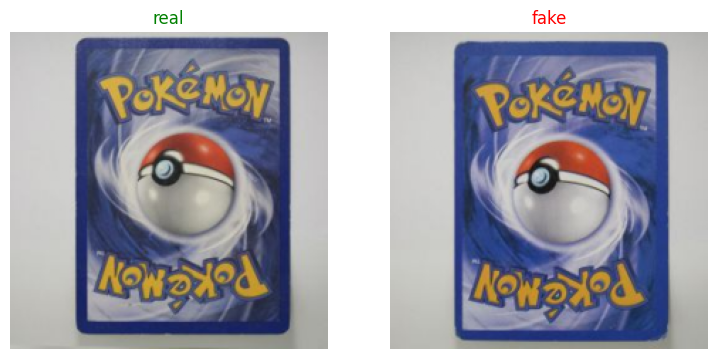

In [90]:
#Now Plot them


rows, columns = 1,2
real_rindex = torch.randint(0,len(real_list), size = [1])
fake_rindex = torch.randint(0,len(fake_list), size = [1])


fig = plt.figure(figsize=(9,9))


random_real_card, random_real_label = real_list[real_rindex]
random_fake_card ,random_fake_label = fake_list[fake_rindex]

###################
fig.add_subplot(rows,columns,1)
plt.imshow(random_real_card.permute(1,2,0))
plt.title(class_names[random_real_label], c="g", fontsize=12)
plt.axis(False)
###################



###################
fig.add_subplot(rows,columns,2)
plt.imshow(random_fake_card.permute(1,2,0))
plt.title(class_names[random_fake_label], c="r", fontsize=12)
plt.axis(False)
###################



## Oberservations

- Real cards have consistent border while the fake ones can have borders that are off

- The color of the real cards are consistent, while the fake ones can vary with them either being darker or lighter than original (However the different lighting can alter the 
real cards as well by adjusting them to be a little dark or lighter than usual)

- Damage of the cards (rips) do no matter when determining if the card is real or fake which is seen with some of the real cards having damage

- Photos are taken differently each time (not all the cards are centered)

- Some cards are upside down
